**This notebook is a sandbox for optimization of Rydberg gates. It includes the design of amplitude-robust gate. We use Rydopt package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [72]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [71]:
pip show rydopt

Name: RydOpt
Version: 0.2.0
Summary: Multiqubit Rydberg Gate Optimizer
Home-page: 
Author: David F. Locher, Sebastian Weber, Jakob Holschbach
Author-email: 
License: MIT License

 Copyright (c) 2025, David Locher, Sebastian Weber, Jakob Holschbach

 Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the “Software”), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

 The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

 THE SOFTWARE IS PROVIDED “AS IS”, WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND N

**Here we optimize CZ gate with constant Rabi frequency and variable phase**

In [73]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)

**Defining pulse shape. Only pulse phase is variable**

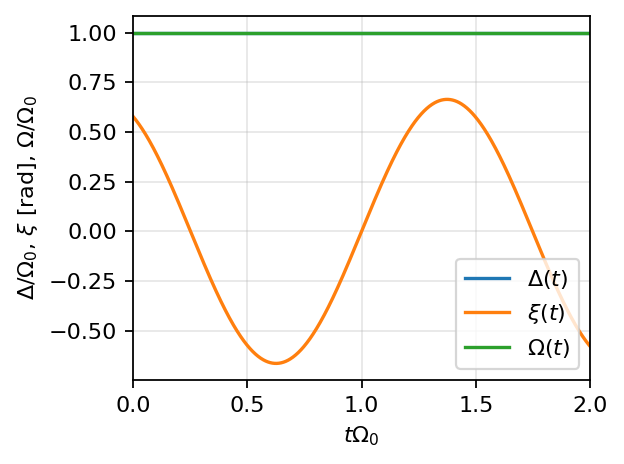

In [74]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
initial_params = (2, [1.0], [0.81977751, 0.66389043], [1.0])
fixed_initial_params = (False, [False], [False, False], [True])
ro.characterization.plot_pulse(pulse_ansatz, initial_params);

In [75]:
initial_params = (7.0, [0.0], [0, 0], [1.0])
fixed_initial_params = (False, [False], [False, False], [True])

**Running optimization**

In [76]:
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, fixed_initial_params, tol=1e-10)
optimized_params = opt_result.params

Started optimization using 1 process

proc00: 100%|██████████| 1000/1000 [00:03<00:00, 282.61it/s, infidelity=7.57e-11, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 10.007 seconds
Gates with infidelity below tol=1.0e-10: 1

Optimized gate:
> infidelity <= tol
> parameters = (7.626643597908442, [0.03125944], [0.81977751 0.66389043], [1.])
> duration = 7.626643597908442


In [35]:
opt_result.infidelity

7.566614002030292e-11

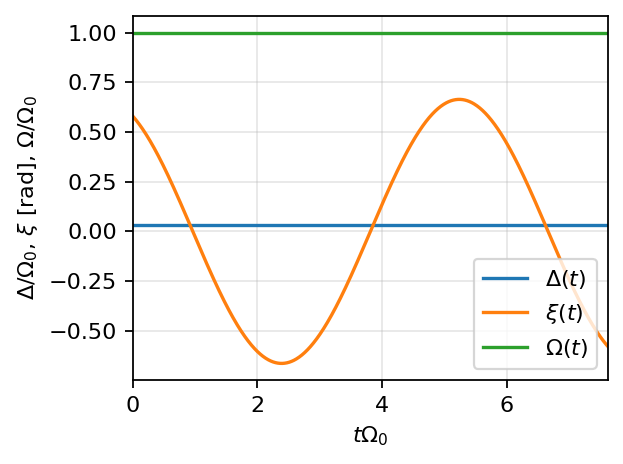

In [6]:
ro.characterization.plot_pulse(pulse_ansatz, optimized_params);

**Checking that the obtained phase shift is correct**

In [7]:
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, optimized_params)
time_evolved_basis_states

(Array([-5.20806905e-01+8.53674511e-01j, -4.14352529e-07-3.47273958e-06j],      dtype=complex128),
 Array([4.57521666e-01+8.89198472e-01j, 1.96958544e-06+1.64245629e-05j],      dtype=complex128))

In [8]:

print("phase shift:", 2*jnp.angle(time_evolved_basis_states[0][0].item())-jnp.angle(time_evolved_basis_states[1][0].item()))

phase shift: 3.1415941483602206


In [9]:
ro.simulation.process_fidelity(gate, pulse_ansatz, optimized_params)


Array(1., dtype=float64)

**Checking robustness**

In [10]:
initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[0.95]
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.9919516, dtype=float64)

**Now lets optimize smooth shape gate**

In [11]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)

initial_params = (4.0, [0.0], [0.0, 0.0], [2.0, 0.3])
fixed_initial_params = (False, [False], [False, False], [True, True])

In [12]:
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, tol=1e-10)
optimized_params = opt_result.params

Started optimization using 1 process

proc00: 100%|██████████| 1000/1000 [00:05<00:00, 180.79it/s, infidelity=1.36e-11, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 10.113 seconds
Gates with infidelity below tol=1.0e-10: 1

Optimized gate:
> infidelity <= tol
> parameters = (4.058348807763706, [-0.09393892], [0.73884332 0.77225565], [2.09722135 0.19713572])
> duration = 4.058348807763706


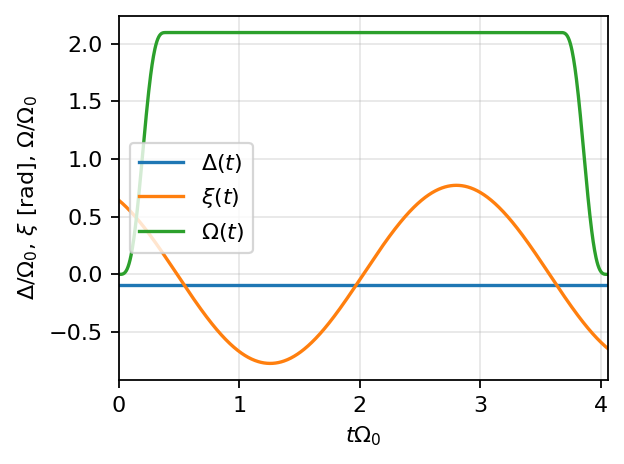

In [13]:
ro.characterization.plot_pulse(pulse_ansatz, optimized_params);

**Lukin-Pichler gate**

In [41]:
def phase_step(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    phase = ansatz_params[0]
    return phase*jnp.heaviside(t-duration/2,1)

In [63]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=phase_step, rabi_ansatz=ro.pulses.const
)
initial_params = (7.0, [0.0], [1.0], [1.0])
fixed_initial_params = (False, [False], [False], [True])

In [65]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
initial_params = (7.0, [0.4], [0.0], [1.0])
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, fixed_initial_params,tol=1e-10)
optimized_params = opt_result.params

Started optimization using 1 process

proc00: 100%|██████████| 1000/1000 [00:06<00:00, 161.18it/s, infidelity=9.62e-11, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 9.543 seconds
Gates with infidelity below tol=1.0e-10: 1

Optimized gate:
> infidelity <= tol
> parameters = (8.585298351276332, [-0.37736709], [2.38074119], [1.])
> duration = 8.585298351276332


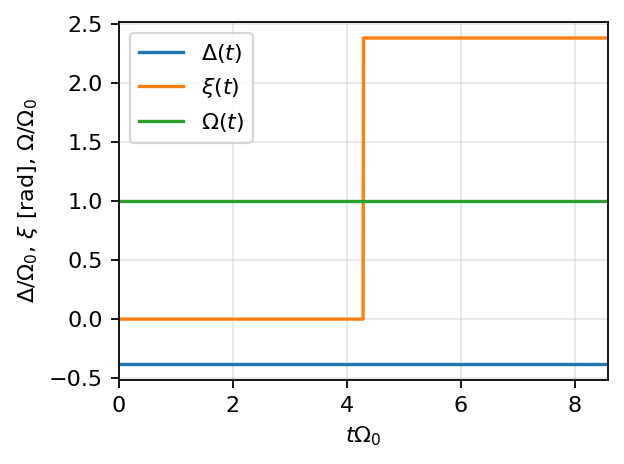

In [17]:
ro.characterization.plot_pulse(pulse_ansatz, optimized_params,  plot_rabi= True);

In [69]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
levine_params1=(8.585308327286219, [-0.37736613], [2.38073847], [1.])
levine_params2=(2*4.29268, [ 0.377371], [3.90242], [1])

time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, levine_params2)
gate.process_fidelity(time_evolved_basis_states)

Array(0.99999999, dtype=float64)

In [70]:
2*4.29268

8.58536

**Checking robustness**

In [18]:
initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[0.95]
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.99260805, dtype=float64)

In [44]:
8.585308327286219/2

4.2926541636431095

In [49]:
Vnnlist=[100,500,1000,2000,4000]
initial_params=(1,[-0.37736613*8.585308327286219],[2.38073847],[8.585308327286219])
FLevine=[]
for i in range(5):
    gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=Vnnlist[i], decay=0.0)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLevine.append(1-  gate.process_fidelity(time_evolved_basis_states).item())
FLevine

[0.0060634541931344765,
 0.00022819957630026977,
 5.662331436684376e-05,
 1.4105048538715081e-05,
 3.522443032921707e-06]

**Here we design the driving Hamiltonian for single-qubit gate by ourselves**

In [19]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt


class XGate:
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1, 0], dtype=complex), jnp.array([0, 1], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            return jnp.array(
                [
                    [0, 0.5 * Omega * jnp.exp(-1j * Xi)],
                    [0.5 * Omega * jnp.exp(1j * Xi), Delta],
                ]
            )

        return hamiltonian, hamiltonian

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        obtained_gate = jnp.stack(final_basis_states, axis=1)
        reduced_gate=obtained_gate[[0, 1], :][:, [0, 1]]
        targeted_gate = jnp.array([[0, 1j], [1j, 0]])
        return jnp.abs(jnp.trace(targeted_gate.conj().T @ reduced_gate)) ** 2 / 4


**Now we optimize gate duration. it should be \pi for constant Rabi frequency**

In [20]:
# Create an instance of our gate class
gate = XGate()

# Pulse ansatz: constant phase
pulse_ansatz = ro.pulses.PulseAnsatz(phase_ansatz=ro.pulses.const)

# Initial pulse parameter guess:
# duration, detuning parameters, phase parameters, Rabi parameters
initial_params = (1.0, [], [1.0], [])

# Optimize the pulse parameters
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params)
optimized_params = opt_result.params

Started optimization using 1 process

proc00: 100%|██████████| 1000/1000 [00:00<00:00, 4474.77it/s, infidelity=2.69e-08, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 3.522 seconds
Gates with infidelity below tol=1.0e-07: 1

Optimized gate:
> infidelity <= tol
> parameters = (3.1417655031181884, [], [-0.00012544], [])
> duration = 3.1417655031181884


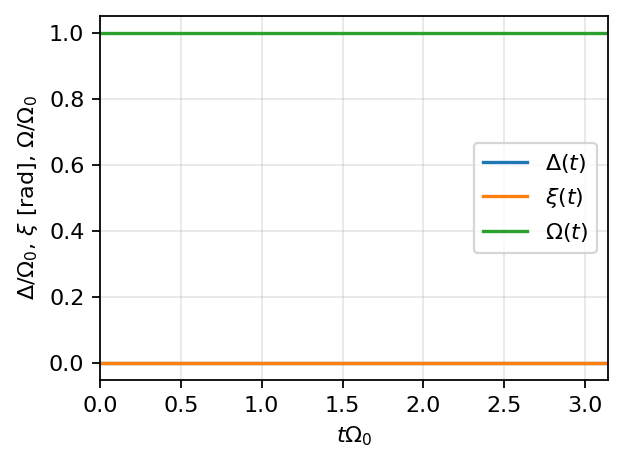

In [21]:
ro.characterization.plot_pulse(pulse_ansatz, optimized_params);

**Here we optimize the counterdiabatic gate. We vary detuning, driving Rabi frequency and counterdiabatic term amplitude**

**Defining analytic pulse shapes**

In [2]:
def double_sin(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    amplitude1 = ansatz_params[0]
    if len(ansatz_params)>1:
        amplitude2=ansatz_params[1]
    else: 
        amplitude2=amplitude1
    t1=0.25*duration
    t2=0.75*duration
    return amplitude1*jnp.sin(2*jnp.pi*(t-t1)/duration)*jnp.heaviside(duration/2-t,0)+amplitude2*jnp.sin(2*jnp.pi*(t-t2)/duration)*jnp.heaviside(t-duration/2,1)
  

In [3]:
def double_exp(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    amplitude1 = ansatz_params[0]
    if len(ansatz_params)>1:
        amplitude2=ansatz_params[1]
    else: 
        amplitude2=amplitude1
    t1=0.25*duration
    t2=0.75*duration
    wt=0.125*duration
    return amplitude1*jnp.exp(-((t-t1)/wt)**4)*jnp.heaviside(duration/2-t,0)+amplitude2*jnp.exp(-((t-t2)/wt)**4)*jnp.heaviside(t-duration/2,1)

In [4]:
def counterdia(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    if len(ansatz_params)>2:
        RabiArray = ansatz_params[0::2]
        Rabi1=RabiArray[0]
        Rabi2=RabiArray[1]
    else: 
        Rabi1=ansatz_params[0]
        Rabi2=Rabi1

    if len(ansatz_params)>3:    
        detuningArray= ansatz_params[1::2]
        detuning1=detuningArray[0]
        detuning2=detuningArray[1]
    else:
        detuning1=ansatz_params[1]
        detuning2=detuning1
    t1=0.25*duration
    t2=0.75*duration
    wt=0.125*duration
    
    
    def Delta(t,t_c=0.0,detuning=detuning1):
        return detuning*(jnp.sin(2*jnp.pi*(t-t_c)/duration))
                         
    def OmegaRe(t,t_c=0.0,Rabi=Rabi1):
        return Rabi*(jnp.exp(-((t-t_c)/wt)**4))
                     
    def Derive(t,t_c=0.0,Rabi=Rabi1,detuning=detuning1):
        return (Delta(t,t_c)*Rabi*4*((t-t_c)**3)*jnp.exp(-((t-t_c)/wt)**4)/(wt**4)+OmegaRe(t,t_c)*detuning*2*jnp.pi*jnp.cos(2*jnp.pi*(t-t_c)/duration)/duration)/(OmegaRe(t,t_c)**2+Delta(t,t_c)**2)
                     
           
    return jnp.heaviside(duration/2-t,0)*Derive(t,t1,Rabi1,detuning1)+jnp.heaviside(t-duration/2,1)*Derive(t,t2,Rabi2,detuning2)

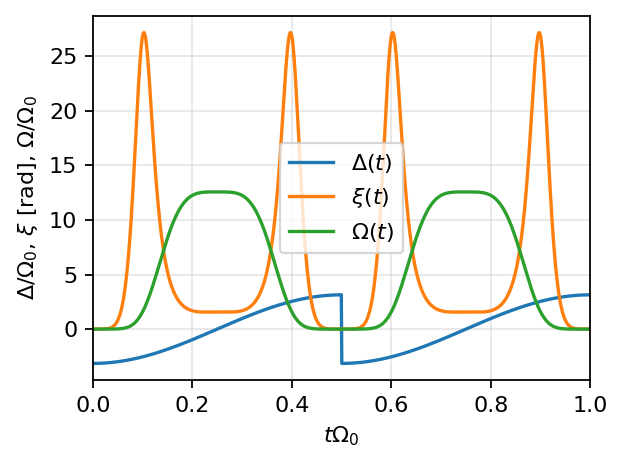

In [51]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
initial_params=(1,[1.0*jnp.pi], [4.0*jnp.pi,1.0*jnp.pi], [4.0*jnp.pi])
fixed_initial_params = (True, [False], [False], [False])
ro.characterization.plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);

**We re-define the CZ gate for perfect blockade to use two phase-shifted pulses in the Hamiltonian instead**

In [52]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt

class CZGateCounter:
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex), jnp.array([1,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
           
            return jnp.array(
                [
                   [0,(Omega-1j*Xi)*0.5],
                   [(Omega+1j*Xi)*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re"""
           
            return jnp.array(
                 [
                   [0,(Omega-1j*Xi)*0.5*jnp.sqrt(2)],
                   [(Omega+1j*Xi)*0.5*jnp.sqrt(2),Delta]
                                                        
                ]
            )
        return hamiltonian1, hamiltonian2

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[0][0],
                final_basis_states[1][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

In [53]:
gate = CZGateCounter()
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params,  tol=1e-10)
optimized_params = opt_result.params

Started optimization using 1 process

proc00: 100%|██████████| 1000/1000 [00:10<00:00, 92.36it/s, infidelity=5.78e-11, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 17.254 seconds
Gates with infidelity below tol=1.0e-10: 1

Optimized gate:
> infidelity <= tol
> parameters = (0.9087144520306829, [3.1538771], [12.53533205  3.18998555], [12.39319698])
> duration = 0.9087144520306829


In [54]:
optimized_params

(np.float64(0.9087144520306829),
 array([3.1538771]),
 array([12.53533205,  3.18998555]),
 array([12.39319698]))

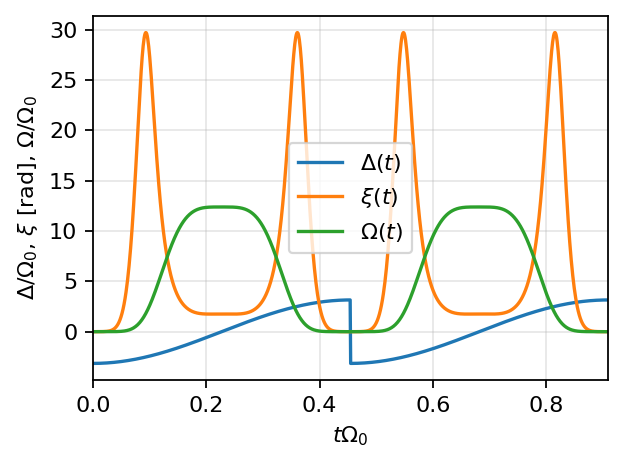

In [55]:
ro.characterization.plot_pulse(pulse_ansatz, optimized_params,  plot_rabi= True);

**Robustness**

In [60]:
initial_params=optimized_params[0],optimized_params[1],[optimized_params[2][0]*1.05,optimized_params[2][1]],[optimized_params[3][0]*1.05]
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.9974193, dtype=float64)

**Counterdiabatic gate with finite blockade**

In [5]:
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt

class CZGateCounterV:
 
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex), jnp.array([1,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
           
            return jnp.array(
                [
                   [0,(Omega-1j*Xi)*0.5],
                   [(Omega+1j*Xi)*0.5,Delta],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re"""
            V=2*jnp.pi*100
            return jnp.array(
                 [
                   [0,(Omega-1j*Xi)*0.5*jnp.sqrt(2),0],
                   [(Omega+1j*Xi)*0.5*jnp.sqrt(2),Delta,(Omega+1j*Xi)*0.5*jnp.sqrt(2)],
                    [0,(Omega-1j*Xi)*0.5*jnp.sqrt(2),2*Delta+V]                                    
                ]



                
            )
        return hamiltonian1, hamiltonian2

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[0][0],
                final_basis_states[1][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

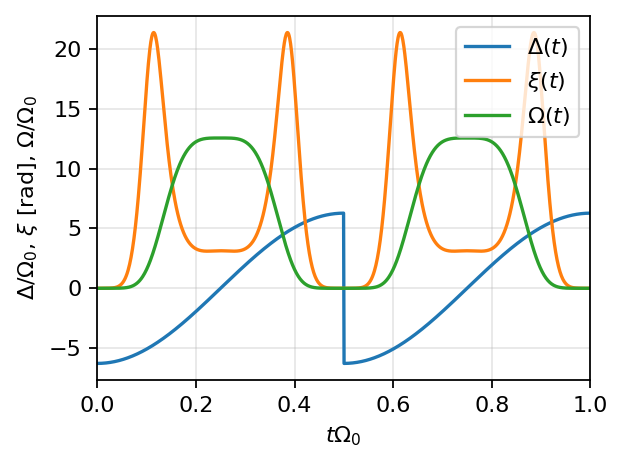

In [7]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
initial_params=(1,[2.0*jnp.pi,2.0*np.pi], [2.003*2*jnp.pi,2.0*jnp.pi,2.003*2*jnp.pi,2.0*jnp.pi], [2.0003*2*jnp.pi, 2.0003*2*jnp.pi])
ro.characterization.plot_pulse(pulse_ansatz, initial_params,  plot_rabi= True);

In [ ]:
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, tol=1e-4,num_steps=2000)


In [46]:
gate = CZGateCounterV()
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, tol=1e-4,num_steps=2000)
optimized_params = opt_result.params

Started optimization using 1 process

proc00: 100%|██████████| 2000/2000 [00:29<00:00, 66.95it/s, infidelity=9.53e-05, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 36.961 seconds
Gates with infidelity below tol=1.0e-04: 1

Optimized gate:
> infidelity <= tol
> parameters = (0.5854374838555904, [10.24609795 12.2050988 ], [10.38955925  3.73248083 15.17676803  4.37576864], [15.979022   15.75457062])
> duration = 0.5854374838555904


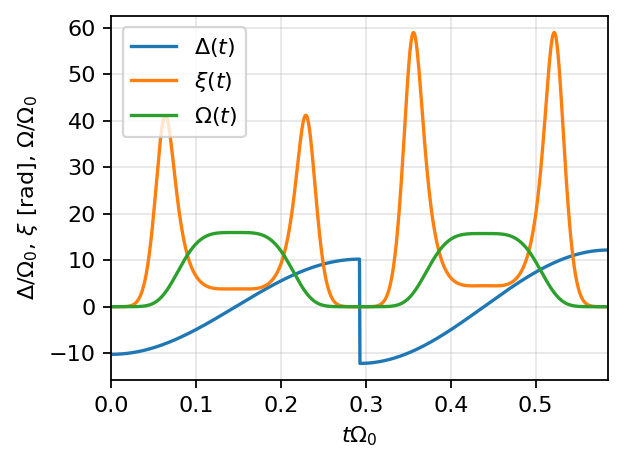

In [47]:
ro.characterization.plot_pulse(pulse_ansatz, optimized_params,  plot_rabi= True);

**Two-photon counterdiabatic gate**

In [15]:
def lin(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    Rabi0 = ansatz_params[0]
    Rabi1 = ansatz_params[1]
    return Rabi0+(Rabi1-Rabi0)*t/duration

In [70]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)

In [72]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=ro.pulses.const
)
initial_params = (7.0, [0.0], [0.0, 0.0], [1.0])
fixed_initial_params = (False, [False], [False, False], [True])

In [73]:
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params, fixed_initial_params, tol=1e-10)
optimized_params = opt_result.params

Started optimization using 1 process

proc00: 100%|██████████| 1000/1000 [00:02<00:00, 379.36it/s, infidelity=7.57e-11, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 7.153 seconds
Gates with infidelity below tol=1.0e-10: 1

Optimized gate:
> infidelity <= tol
> parameters = (7.626643597908442, [0.03125944], [0.81977751 0.66389043], [1.])
> duration = 7.626643597908442


In [88]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.sin_crab,rabi_ansatz=lin
)
initial_params=optimized_params[0],optimized_params[1],optimized_params[2],[0.95*optimized_params[3][0],optimized_params[3][0]*1.05]
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states)


Array(0.99568926, dtype=float64)

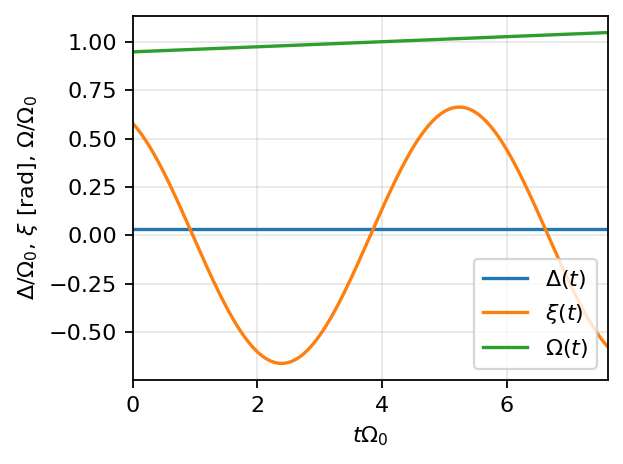

In [89]:
ro.characterization.plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);

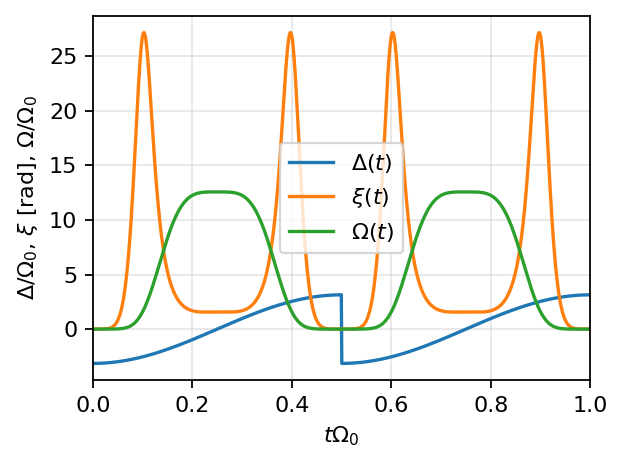

In [90]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
initial_params=(1,[1.0*jnp.pi], [4.0*jnp.pi,1.0*jnp.pi], [4.0*jnp.pi])
fixed_initial_params = (True, [False], [False], [False])
ro.characterization.plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);

In [91]:
gate = CZGateCounter()
opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params,  tol=1e-10)
optimized_params = opt_result.params

Started optimization using 1 process

proc00: 100%|██████████| 1000/1000 [00:10<00:00, 91.52it/s, infidelity=5.78e-11, converged=1/1]

=== Optimization finished using Adam ===

Runtime: 16.678 seconds
Gates with infidelity below tol=1.0e-10: 1

Optimized gate:
> infidelity <= tol
> parameters = (0.9087144520306829, [3.1538771], [12.53533205  3.18998555], [12.39319698])
> duration = 0.9087144520306829


In [93]:
initial_params=optimized_params[0],optimized_params[1],[optimized_params[2][0]*0.95,optimized_params[2][1],optimized_params[2][0]*1.05,optimized_params[2][1]],[optimized_params[3][0]*0.95,optimized_params[3][0]*1.05]
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.99665806, dtype=float64)

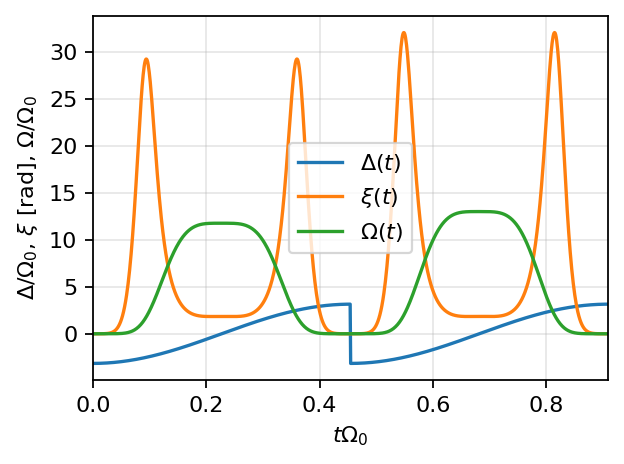

In [94]:
ro.characterization.plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);

**Optimizing robustness for variation of Rabi frequency**

In [3]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab
)
min_initial_params = (7, [-1], [-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1], [])
max_initial_params = (20, [1], [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1], [])

In [4]:
opt_result = ro.optimization.multi_start_optimize(
    gate,
    pulse_ansatz,
    min_initial_params,
    max_initial_params,
    num_steps=1000,
    tol=1e-5,
    num_initializations=180,
    num_processes=8,
    return_history=True,
    return_all=True,
)

Padding num_initializations from 180 to 184 to be a multiple of num_processes=8.
Started optimization using 8 processes






proc05:   0%|          | 0/1000 [00:00<?, ?it/s]




proc05:   0%|          | 1/1000 [00:00<00:00, 1379.25it/s, infidelity=1.45e-01, converged=0/23]






proc07:   0%|          | 0/1000 [00:00<?, ?it/s]






proc07:   0%|          | 1/1000 [00:00<00:00, 1458.38it/s, infidelity=3.04e-01, converged=0/23]


proc03:   0%|          | 0/1000 [00:00<?, ?it/s]


proc00:   0%|          | 1/1000 [00:00<00:00, 3960.63it/s, infidelity=3.17e-01, converged=0/23][A



proc04:   0%|          | 0/1000 [00:00<?, ?it/s]



proc01:   0%|          | 1/1000 [00:00<00:00, 1431.01it/s, infidelity=1.93e-01, converged=0/23]

proc02:   0%|          | 0/1000 [00:00<?, ?it/s]

proc02:   0%|          | 1/1000 [00:00<00:00, 1807.11it/s, infidelity=9.72e-02, converged=0/23]





proc06:   0%|          | 0/1000 [00:00<?, ?it/s]





proc06:   0%|          | 1/1000 [00:00<00:00, 1677.72it/s, i

In [5]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const
)
new_list = []
ll=len(opt_result.params)
for k in range(ll):
    F=0
    print(f"Iteration {k}:")
    for j in range(3):
        initial_params=opt_result.params[k][0],opt_result.params[k][1],opt_result.params[k][2],[0.95+0.05*j]  
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
        F=F+gate.process_fidelity(time_evolved_basis_states)/3
    new_list.append(F.item())
new_list

Iteration 0:
Iteration 1:
Iteration 2:
Iteration 3:
Iteration 4:
Iteration 5:
Iteration 6:
Iteration 7:
Iteration 8:
Iteration 9:
Iteration 10:
Iteration 11:
Iteration 12:
Iteration 13:
Iteration 14:
Iteration 15:
Iteration 16:
Iteration 17:
Iteration 18:
Iteration 19:
Iteration 20:
Iteration 21:
Iteration 22:
Iteration 23:
Iteration 24:
Iteration 25:
Iteration 26:
Iteration 27:
Iteration 28:
Iteration 29:
Iteration 30:
Iteration 31:
Iteration 32:
Iteration 33:
Iteration 34:
Iteration 35:
Iteration 36:
Iteration 37:
Iteration 38:
Iteration 39:
Iteration 40:
Iteration 41:
Iteration 42:
Iteration 43:
Iteration 44:
Iteration 45:
Iteration 46:
Iteration 47:
Iteration 48:
Iteration 49:
Iteration 50:
Iteration 51:
Iteration 52:
Iteration 53:
Iteration 54:
Iteration 55:
Iteration 56:
Iteration 57:
Iteration 58:
Iteration 59:
Iteration 60:
Iteration 61:
Iteration 62:
Iteration 63:
Iteration 64:
Iteration 65:
Iteration 66:
Iteration 67:
Iteration 68:
Iteration 69:
Iteration 70:
Iteration 71:
It

[0.9953873692183559,
 0.9969553876228052,
 0.9947276457961305,
 0.9977000518175685,
 0.9925322597442794,
 0.989488453587771,
 0.9320751431442758,
 0.994354210153175,
 0.9949329233163489,
 0.9986860376906259,
 0.9944612664024419,
 0.9954166457015805,
 0.9766893511966723,
 0.9945206736940326,
 0.9957242001096738,
 0.992988459826132,
 0.9961838157313285,
 0.9940965588267381,
 0.9773271009986908,
 0.9971105490847931,
 0.9971846741317323,
 0.9616932059095324,
 0.9887815803570503,
 0.9799374603128006,
 0.9957396021212793,
 0.9963541735447714,
 0.9884759972256425,
 0.9737305535743924,
 0.9562795275793856,
 0.9970085554587259,
 0.9895247790791619,
 0.9924990813329277,
 0.994332142634955,
 0.9983193768557557,
 0.996242815107075,
 0.993970355865383,
 0.9960743648266999,
 0.9951195731829714,
 0.9952007984034508,
 0.9995724253765255,
 0.9887279081636746,
 0.994723973430673,
 0.9943182768846253,
 0.9942787370999848,
 0.993597689578904,
 0.9935435653105849,
 0.9919692306180068,
 0.9940124894901441,


In [6]:
max_element = max(new_list)
max_element

0.9995724253765255

In [7]:
max_index = new_list.index(max_element)
max_index

39

In [8]:
opt_result.params[max_index]

(np.float64(13.890724697699257),
 array([0.53419984]),
 array([-0.29764246, -0.50525265, -0.99694164, -1.10879253,  0.38720574,
        -0.03933725,  0.7180595 ,  0.42690275,  0.3036199 , -0.90893801,
         0.56443475,  0.619433  , -0.67509563,  1.55462273, -0.16086264,
        -0.05593501,  0.0698354 ]),
 array([], dtype=float64))

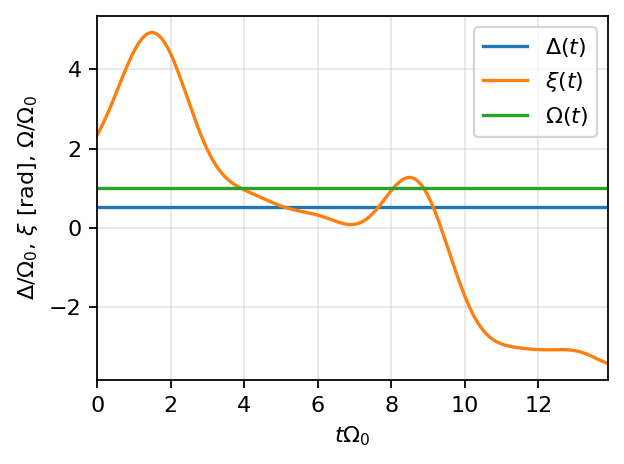

In [9]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const
)
params=opt_result.params[max_index][0],opt_result.params[max_index][1],opt_result.params[max_index][2],[1]
ro.characterization.plot_pulse(pulse_ansatz, params,   plot_rabi= True);

In [13]:
params=opt_result.params[max_index][0],opt_result.params[max_index][1],opt_result.params[max_index][2],[0.95]
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.99953714, dtype=float64)

In [16]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=lin
)

params=opt_result.params[max_index][0],opt_result.params[max_index][1],opt_result.params[max_index][2],[0.95,1.05]
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.9941727, dtype=float64)

In [31]:
gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab
)
min_initial_params = (7, [-1], [-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1], [])
max_initial_params = (20, [1], [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1], [])
opt_result = ro.optimization.multi_start_optimize(
    gate,
    pulse_ansatz,
    min_initial_params,
    max_initial_params,
    num_steps=1000,
    tol=1e-5,
    num_initializations=180,
    num_processes=8,
    return_history=True,
    return_all=True,
)

Padding num_initializations from 180 to 184 to be a multiple of num_processes=8.
Started optimization using 8 processes







proc06:   0%|          | 0/1000 [00:00<?, ?it/s]





proc00:   0%|          | 1/1000 [00:00<00:00, 3622.02it/s, infidelity=1.36e-01, converged=0/23]

proc02:   0%|          | 0/1000 [00:00<?, ?it/s]

proc02:   0%|          | 1/1000 [00:00<00:01, 846.65it/s, infidelity=6.38e-02, converged=0/23]






proc07:   0%|          | 0/1000 [00:00<?, ?it/s]






proc07:   0%|          | 1/1000 [00:00<00:00, 1163.47it/s, infidelity=1.26e-01, converged=0/23]




proc05:   0%|          | 0/1000 [00:00<?, ?it/s]




proc05:   0%|          | 1/1000 [00:00<00:01, 519.48it/s, infidelity=2.46e-01, converged=0/23]



proc04:   0%|          | 0/1000 [00:00<?, ?it/s]



proc01:   0%|          | 1/1000 [00:00<00:00, 1157.37it/s, infidelity=1.21e-01, converged=0/23]


proc03:   0%|          | 0/1000 [00:00<?, ?it/s]


proc03:   0%|          | 1/1000 [00:00<00:01, 870.91it/s, infide

In [32]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const
)
new_list = []
ll=len(opt_result.params)
for k in range(ll):
    F=0
    print(f"Iteration {k}:")
    for j in range(3):
        initial_params=opt_result.params[k][0],opt_result.params[k][1],opt_result.params[k][2],[0.95+0.05*j]  
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
        F=F+gate.process_fidelity(time_evolved_basis_states)/3
    new_list.append(F.item())
new_list

Iteration 0:
Iteration 1:
Iteration 2:
Iteration 3:
Iteration 4:
Iteration 5:
Iteration 6:
Iteration 7:
Iteration 8:
Iteration 9:
Iteration 10:
Iteration 11:
Iteration 12:
Iteration 13:
Iteration 14:
Iteration 15:
Iteration 16:
Iteration 17:
Iteration 18:
Iteration 19:
Iteration 20:
Iteration 21:
Iteration 22:
Iteration 23:
Iteration 24:
Iteration 25:
Iteration 26:
Iteration 27:
Iteration 28:
Iteration 29:
Iteration 30:
Iteration 31:
Iteration 32:
Iteration 33:
Iteration 34:
Iteration 35:
Iteration 36:
Iteration 37:
Iteration 38:
Iteration 39:
Iteration 40:
Iteration 41:
Iteration 42:
Iteration 43:
Iteration 44:
Iteration 45:
Iteration 46:
Iteration 47:
Iteration 48:
Iteration 49:
Iteration 50:
Iteration 51:
Iteration 52:
Iteration 53:
Iteration 54:
Iteration 55:
Iteration 56:
Iteration 57:
Iteration 58:
Iteration 59:
Iteration 60:
Iteration 61:
Iteration 62:
Iteration 63:
Iteration 64:
Iteration 65:
Iteration 66:
Iteration 67:
Iteration 68:
Iteration 69:
Iteration 70:
Iteration 71:
It

[0.9876911735775438,
 0.995255573929148,
 0.9883436999477377,
 0.9939349900746934,
 0.9958365919626528,
 0.9941700107021265,
 0.9938155972187095,
 0.986296359818088,
 0.9961758923169832,
 0.9985053754676159,
 0.9885824537680232,
 0.9951541136196296,
 0.9950599881386397,
 0.9945171213255719,
 0.9917250544171028,
 0.9685705321929579,
 0.9958414346151742,
 0.9962736766105551,
 0.9658066451332037,
 0.9956140595653904,
 0.9748384206831124,
 0.9885733989850987,
 0.9534732967866824,
 0.982425547052088,
 0.9930058727059994,
 0.9788103431948325,
 0.9942388795237889,
 0.9964430139621406,
 0.9924162738136804,
 0.9949711789229077,
 0.9937690052420024,
 0.9947082890052222,
 0.9885305779489364,
 0.995604347962207,
 0.995622600728169,
 0.9987256668007646,
 0.9973239190835408,
 0.9945613273179335,
 0.9955332147482833,
 0.9893279186804144,
 0.9942822685570636,
 0.9957923531984192,
 0.996859015438089,
 0.9951248243864865,
 0.9792383557424649,
 0.99460713689202,
 0.9947192529964088,
 0.9665503734403134,


In [42]:
max_element = max(new_list)
max_element

0.9996526361237035

In [43]:
max_index = new_list.index(max_element)
max_index

112

**Optimal parameters for robust pulse**

In [93]:
opt_result.params[max_index]

(np.float64(15.560089695727132),
 array([-0.66202403]),
 array([ 0.51990003, -0.2527502 ,  0.8859972 , -1.17347235, -0.08802893,
        -0.327713  , -1.00445164,  0.10583959,  1.20175343,  0.62878523,
         0.65908966, -0.25679209, -0.56651597,  1.10736928, -0.32141791,
         0.14352779, -0.2186016 ]),
 array([], dtype=float64))

In [96]:
params=opt_result.params[max_index][0],opt_result.params[max_index][1],opt_result.params[max_index][2],[0.95]
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.99941335, dtype=float64)

In [38]:
from rydopt.pulses.pulse_ansatz import PulseAnsatz
from typing import cast
from rydopt.types import PulseParams
def pulse_plot(pulse: PulseAnsatz, params: PulseParams)-> tuple[plt.Figure, plt.Axes]:
    duration = params[0]
    times = jnp.linspace(0, duration, 1024)
    values = np.array(pulse.evaluate_pulse_functions(times, params))
    fig, ax = plt.subplots(figsize=(8, 6))
    plt.rcParams.update({'font.size': 12})
    plt.rcParams['lines.linewidth'] = 2
    for v in (values):
        ax.plot(times, v)
    ax.set_xmargin(0)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig('my_plot.svg', format='svg')
    return fig, ax